In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [8]:
# Download ETF DATA

tickers = ["SPY","QQQ","TLT","GLD","SHY"]
prices = yf.download(
    tickers,
    start = "2015-01-01",
    auto_adjust = True,
    progress = False
)["Open"]

prices.head()

    
    

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-01-02,112.489998,95.419145,68.853317,170.911759,92.611983
2015-01-05,114.779999,94.251278,68.837021,169.081571,93.873293
2015-01-06,116.220001,93.414376,68.910357,167.358997,95.845981
2015-01-07,116.470001,92.632705,68.934882,166.804154,95.845969
2015-01-08,116.449997,94.002932,68.951134,168.949020,95.596618


In [11]:
# checking rows and column
print(prices.shape)

(2858, 5)


In [12]:
# checking missing values
print(prices.isna().sum())

Ticker
GLD    0
QQQ    0
SHY    0
SPY    0
TLT    0
dtype: int64


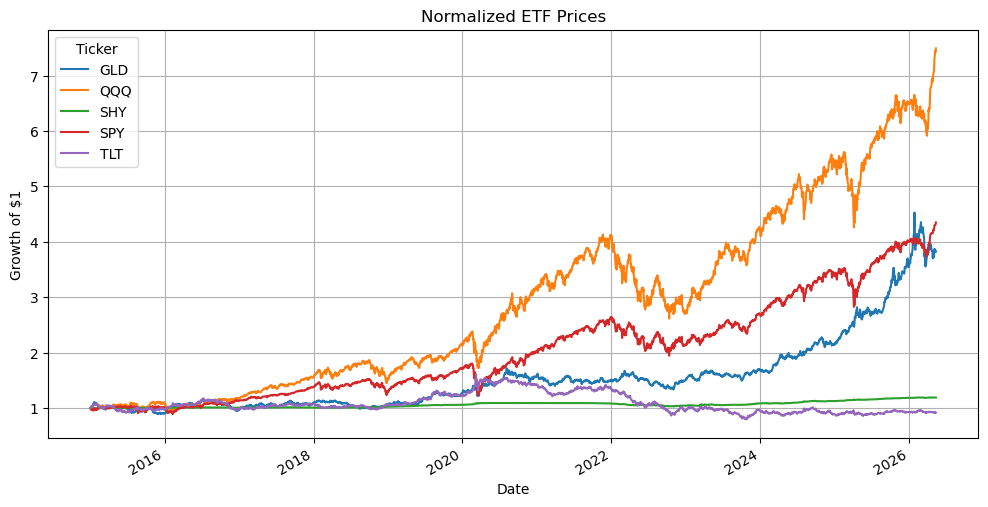

In [13]:
# ETF have different starting vaues, so normalization makes them comparable
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12,6))

plt.title("Normalized ETF Prices")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [14]:
#calculate returns
returns = prices.pct_change().dropna()

returns.head()

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-01-05,0.020357,-0.012239,-0.000237,-0.010708,1.361929e-02
2015-01-06,0.012546,-0.008879,0.001065,-0.010188,2.101438e-02
2015-01-07,0.002151,-0.008368,0.000356,-0.003315,-1.302396e-07
2015-01-08,-0.000172,0.014792,0.000236,0.012859,-2.601574e-03
2015-01-09,0.000515,0.013696,0.000710,0.011715,-8.898535e-03


In [15]:
# Market features

spy = prices["SPY"]
spy_returns = spy.pct_change()

features = pd.DataFrame(index=prices.index)

features["ret_21d"] = spy.pct_change(21)
features["ret_63d"] = spy.pct_change(63)

features["vol_21d"] = spy_returns.rolling(21).std() * np.sqrt(252)
features["vol_63d"] = spy_returns.rolling(63).std() * np.sqrt(252)

ma50 = spy.rolling(50).mean()
ma200 = spy.rolling(200).mean()

features["trend_50_200"] = ma50 / ma200 - 1

rolling_peak = spy.cummax()
features["drawdown"] = spy / rolling_peak - 1

features = features.dropna()

features.head()

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown
Date,,,,,,
2015-10-16,0.019320,-0.041671,0.204064,0.247872,-0.030886,-0.041671
2015-10-19,0.034694,-0.041789,0.194317,0.247874,-0.031313,-0.043230
2015-10-20,0.032631,-0.033307,0.194177,0.247560,-0.031875,-0.041577
2015-10-21,0.050186,-0.032437,0.186804,0.247615,-0.032399,-0.037986
2015-10-22,0.045696,-0.029789,0.187741,0.247433,-0.032804,-0.040962


In [16]:
scaler = StandardScaler()

X = scaler.fit_transform(features)

X[:5]

array([[ 1.43688083e-01, -1.12556294e+00,  6.41469321e-01,
         1.20181052e+00, -1.53212671e+00,  2.86283762e-02],
       [ 4.82047565e-01, -1.12726904e+00,  5.31363210e-01,
         1.20183675e+00, -1.54148098e+00,  1.22455408e-03],
       [ 4.36636036e-01, -1.00474784e+00,  5.29778528e-01,
         1.19779266e+00, -1.55378645e+00,  3.02811346e-02],
       [ 8.23007260e-01, -9.92180755e-01,  4.46494937e-01,
         1.19849868e+00, -1.56525758e+00,  9.33841937e-02],
       [ 7.24190706e-01, -9.53937384e-01,  4.57074210e-01,
         1.19615817e+00, -1.57412591e+00,  4.10822431e-02]])

In [17]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

features["cluster"] = kmeans.fit_predict(X)

features.head()

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown,cluster
Date,,,,,,,
2015-10-16,0.019320,-0.041671,0.204064,0.247872,-0.030886,-0.041671,2
2015-10-19,0.034694,-0.041789,0.194317,0.247874,-0.031313,-0.043230,2
2015-10-20,0.032631,-0.033307,0.194177,0.247560,-0.031875,-0.041577,2
2015-10-21,0.050186,-0.032437,0.186804,0.247615,-0.032399,-0.037986,2
2015-10-22,0.045696,-0.029789,0.187741,0.247433,-0.032804,-0.040962,2


In [18]:
regime_summary = features.groupby("cluster")[[
    "ret_21d",
    "ret_63d",
    "vol_21d",
    "vol_63d",
    "trend_50_200",
    "drawdown"
]].mean()

regime_summary

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown
cluster,,,,,,
0,0.017899,0.059199,0.113993,0.119807,0.059509,-0.017418
1,-0.060099,-0.068592,0.271365,0.225809,-0.003771,-0.141061
2,0.055902,0.014070,0.206598,0.272047,-0.029638,-0.088179


In [19]:
features["regime"] = features["cluster"].map({
    0: "Bullish",
    1: "Defensive",
    2: "High Volatility"
})

features[["cluster", "regime"]].head()

,cluster,regime
Date,,
2015-10-16,2,High Volatility
2015-10-19,2,High Volatility
2015-10-20,2,High Volatility
2015-10-21,2,High Volatility
2015-10-22,2,High Volatility


In [20]:
def get_weights(regime):

    if regime == "Bullish":

        return {
            "SPY": 0.35,
            "QQQ": 0.35,
            "TLT": 0.10,
            "GLD": 0.10,
            "SHY": 0.10
        }

    elif regime == "Defensive":

        return {
            "SPY": 0.20,
            "QQQ": 0.15,
            "TLT": 0.30,
            "GLD": 0.20,
            "SHY": 0.15
        }

    else:

        return {
            "SPY": 0.10,
            "QQQ": 0.05,
            "TLT": 0.35,
            "GLD": 0.25,
            "SHY": 0.25
        }

In [21]:
weights = pd.DataFrame(
    index=features.index,
    columns=tickers
)

for date in features.index:

    regime = features.loc[date, "regime"]

    weights.loc[date] = get_weights(regime)

weights.head()

,SPY,QQQ,TLT,GLD,SHY
Date,,,,,
2015-10-16,0.1,0.05,0.35,0.25,0.25
2015-10-19,0.1,0.05,0.35,0.25,0.25
2015-10-20,0.1,0.05,0.35,0.25,0.25
2015-10-21,0.1,0.05,0.35,0.25,0.25
2015-10-22,0.1,0.05,0.35,0.25,0.25


In [22]:
aligned_returns = returns.loc[weights.index]

aligned_returns.head()

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-10-16,0.000353,0.014861,-1.178540e-04,0.013745,-0.000483
2015-10-19,-0.005298,0.000741,3.565602e-07,-0.001627,-0.003702
2015-10-20,-0.002308,0.005279,-4.703267e-04,0.001728,-0.007997
2015-10-21,-0.000089,0.001658,1.176314e-04,0.003747,0.006596
2015-10-22,-0.007564,-0.002300,3.528178e-04,-0.003094,0.003964


In [23]:
# back strategy
strategy_returns = (
    aligned_returns * weights.shift(1)
).sum(axis=1)

strategy_returns.head()

Date
2015-10-16           0
2015-10-19   -0.002746
2015-10-20   -0.003057
2015-10-21    0.002773
2015-10-22    -0.00084
dtype: object

In [24]:
strategy_curve = (
    1 + strategy_returns
).cumprod()

benchmark_curve = (
    1 + aligned_returns["SPY"]
).cumprod()

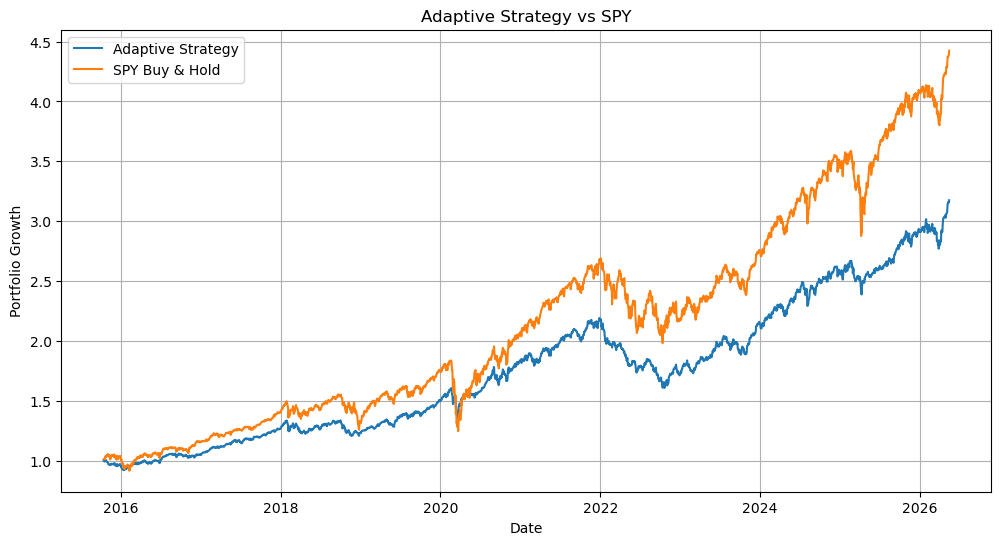

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    strategy_curve,
    label="Adaptive Strategy"
)

plt.plot(
    benchmark_curve,
    label="SPY Buy & Hold"
)

plt.title("Adaptive Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth")

plt.legend()

plt.grid(True)

plt.show()

In [26]:
# sharpe ratio
def sharpe_ratio(returns):

    return (
        np.sqrt(252)
        * returns.mean()
        / returns.std()
    )

strategy_sharpe = sharpe_ratio(strategy_returns)

benchmark_sharpe = sharpe_ratio(
    aligned_returns["SPY"]
)

print("Strategy Sharpe Ratio:",
      round(strategy_sharpe, 3))

print("SPY Sharpe Ratio:",
      round(benchmark_sharpe, 3))

Strategy Sharpe Ratio: 1.09
SPY Sharpe Ratio: 0.91


In [27]:
def max_drawdown(curve):

    running_peak = curve.cummax()

    drawdown = (
        curve / running_peak
    ) - 1

    return drawdown.min()

strategy_mdd = max_drawdown(
    strategy_curve
)

benchmark_mdd = max_drawdown(
    benchmark_curve
)

print("Strategy Max Drawdown:",
      round(strategy_mdd, 3))

print("SPY Max Drawdown:",
      round(benchmark_mdd, 3))

Strategy Max Drawdown: -0.267
SPY Max Drawdown: -0.32


In [28]:
def cagr(curve):

    total_return = (
        curve.iloc[-1]
        / curve.iloc[0]
    ) - 1

    years = len(curve) / 252

    return (
        (1 + total_return)
        ** (1 / years)
    ) - 1

strategy_cagr = cagr(strategy_curve)

benchmark_cagr = cagr(
    benchmark_curve
)

print("Strategy CAGR:",
      round(strategy_cagr, 3))

print("SPY CAGR:",
      round(benchmark_cagr, 3))

Strategy CAGR: 0.116
SPY CAGR: 0.15


In [29]:
strategy_volatility = (
    strategy_returns.std()
    * np.sqrt(252)
)

benchmark_volatility = (
    aligned_returns["SPY"].std()
    * np.sqrt(252)
)

print("Strategy Volatility:",
      round(strategy_volatility, 3))

print("SPY Volatility:",
      round(benchmark_volatility, 3))

Strategy Volatility: 0.106
SPY Volatility: 0.171


In [30]:
summary = pd.DataFrame({

    "Metric": [
        "CAGR",
        "Sharpe Ratio",
        "Max Drawdown",
        "Annual Volatility"
    ],

    "Adaptive Strategy": [
        strategy_cagr,
        strategy_sharpe,
        strategy_mdd,
        strategy_volatility
    ],

    "SPY": [
        benchmark_cagr,
        benchmark_sharpe,
        benchmark_mdd,
        benchmark_volatility
    ]

})

summary

,Metric,Adaptive Strategy,SPY
0,CAGR,0.115713,0.149844
1,Sharpe Ratio,1.089528,0.910419
2,Max Drawdown,-0.266740,-0.320490
3,Annual Volatility,0.105650,0.170938
